# Discharge Calculations 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# import depth data and make date the index
depth_2021 = pd.read_csv('2021_depths.csv', index_col='Date_Time', parse_dates=True)
depth_2022 = pd.read_csv('2022_depths.csv', index_col='Date_Time', parse_dates=True)
depth_2023 = pd.read_csv('2023_depths.csv', index_col='Date_Time', parse_dates=True)

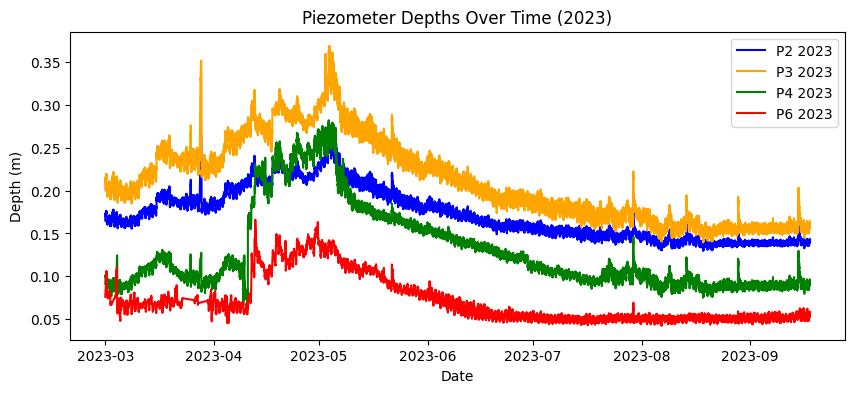

In [3]:
# plot depth over time
plt.figure(figsize=(10, 4))
plt.plot(depth_2023.index, depth_2023['P2'], label='P2 2023', color='blue')
plt.plot(depth_2023.index, depth_2023['P3'], label='P3 2023', color='orange')
plt.plot(depth_2023.index, depth_2023['P4'], label='P4 2023', color='green')
plt.plot(depth_2023.index, depth_2023['P6'], label='P6 2023', color='red')
plt.xlabel('Date')
plt.ylabel('Depth (m)')
plt.title('Piezometer Depths Over Time (2023)')
plt.legend()
plt.show()

### Calculate Q using P3 rating curve: 

In [4]:
###     original rating curve with linear cap ###
def calculate_discharge(depth): 
    if depth > 0.1961466362683:
        return 1.6301*depth - 0.303 
    else:
        return 406.52 * (depth)** 6.1991 

# Q in m3/s, depth in m
discharge_2021 = pd.DataFrame(index=depth_2021.index)
discharge_2022 = pd.DataFrame(index=depth_2022.index)
discharge_2023 = pd.DataFrame(index=depth_2023.index)

discharge_2021['P3'] = depth_2021['P3'].apply(calculate_discharge) 
discharge_2022['P3'] = depth_2022['P3'].apply(calculate_discharge)
discharge_2023['P3'] = depth_2023['P3'].apply(calculate_discharge)

discharge_2023

,P3
Date_Time,
2023-03-01 00:00:00,0.025232
2023-03-01 00:15:00,0.029946
2023-03-01 00:30:00,0.034671
2023-03-01 00:45:00,0.034671
2023-03-01 01:00:00,0.029973
...,...
2023-09-17 22:45:00,0.005021
2023-09-17 23:00:00,0.004454
2023-09-17 23:15:00,0.004454


### Calculate Q using average h

In [5]:
depth_2021['avg'] = depth_2021[['P2', 'P3', 'P4', 'P6']].mean(axis=1)
depth_2022['avg'] = depth_2022[['P2', 'P3', 'P4', 'P6']].mean(axis=1)
depth_2023['avg'] = depth_2023[['P2', 'P3', 'P4', 'P6']].mean(axis=1)

In [6]:
###     original rating curve with linear cap ###
def calculate_discharge(depth): 
    if depth > 0.1100178434789:
        return 1.6417*depth - 0.1637 
    else:
        return 82.831 * (depth)** 3.8495 

discharge_2021['avg'] = depth_2021['avg'].apply(calculate_discharge) 
discharge_2022['avg'] = depth_2022['avg'].apply(calculate_discharge)
discharge_2023['avg'] = depth_2023['avg'].apply(calculate_discharge)

discharge_2023

,P3,avg
Date_Time,,
2023-03-01 00:00:00,0.025232,0.055494
2023-03-01 00:15:00,0.029946,0.058628
2023-03-01 00:30:00,0.034671,0.062935
2023-03-01 00:45:00,0.034671,0.061946
2023-03-01 01:00:00,0.029973,0.060459
...,...,...
2023-09-17 22:45:00,0.005021,0.022821
2023-09-17 23:00:00,0.004454,0.019028
2023-09-17 23:15:00,0.004454,0.019028


### Calculate Q using agerage no P6

In [7]:
depth_2021['avg_nop6'] = depth_2021[['P2', 'P3', 'P4']].mean(axis=1)
depth_2022['avg_nop6'] = depth_2022[['P2', 'P3', 'P4']].mean(axis=1)
depth_2023['avg_nop6'] = depth_2023[['P2', 'P3', 'P4']].mean(axis=1)

In [8]:
###     original rating curve with linear cap ###
def calculate_discharge(depth): 
    if depth > 0.1327542474635:
        return 1.5214*depth - 0.1852
    else:
        return 92.064 * (depth)** 4.2642

discharge_2021['avg_nop6'] = depth_2021['avg_nop6'].apply(calculate_discharge) 
discharge_2022['avg_nop6'] = depth_2022['avg_nop6'].apply(calculate_discharge)
discharge_2023['avg_nop6'] = depth_2023['avg_nop6'].apply(calculate_discharge)

discharge_2023

,P3,avg,avg_nop6
Date_Time,,,
2023-03-01 00:00:00,0.025232,0.055494,0.047030
2023-03-01 00:15:00,0.029946,0.058628,0.050271
2023-03-01 00:30:00,0.034671,0.062935,0.055001
2023-03-01 00:45:00,0.034671,0.061946,0.053226
2023-03-01 01:00:00,0.029973,0.060459,0.050878
...,...,...,...
2023-09-17 22:45:00,0.005021,0.022821,0.016626
2023-09-17 23:00:00,0.004454,0.019028,0.015330
2023-09-17 23:15:00,0.004454,0.019028,0.015330


### Plots for comparison

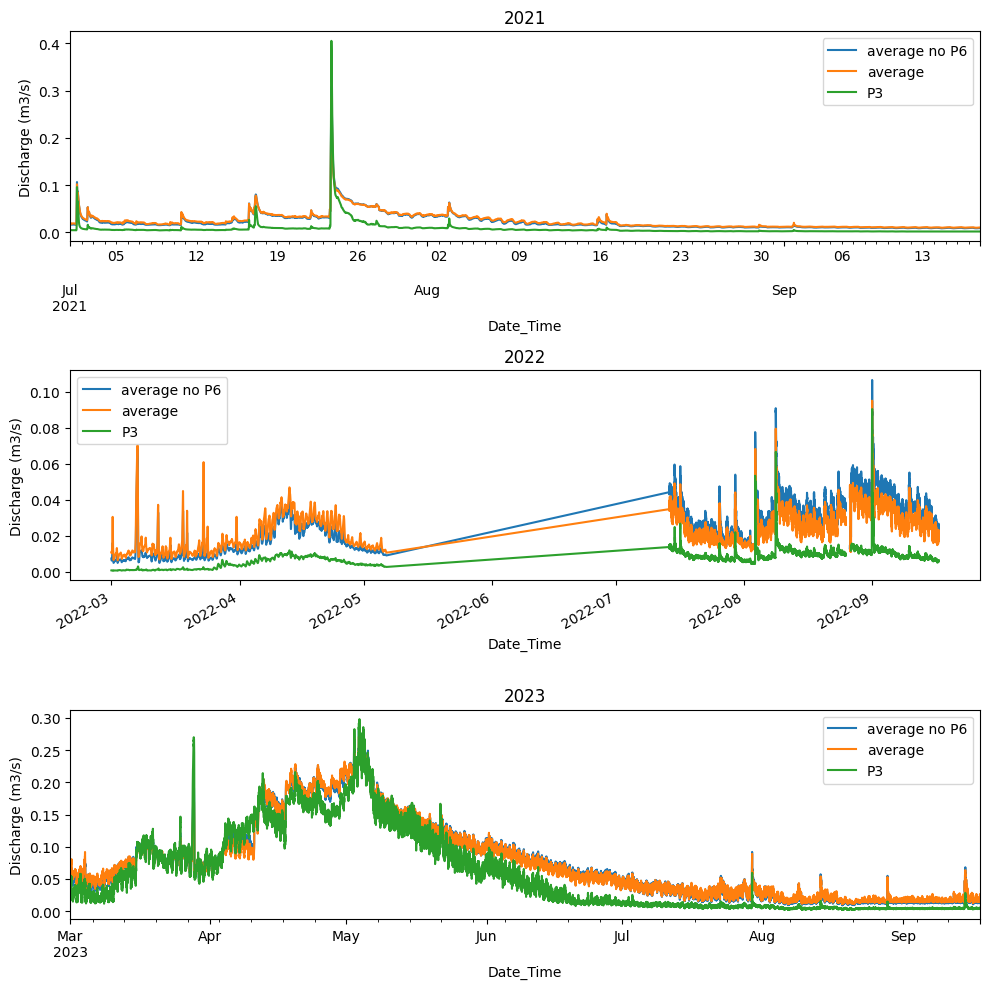

In [9]:
# plot of velocities for each piezometer in one fig
fig, ax = plt.subplots(3, 1, figsize=(10, 10))

discharge_2021['avg_nop6'].plot(ax=ax[0], label='average no P6')
discharge_2021['avg'].plot(ax=ax[0], label='average')
discharge_2021['P3'].plot(ax=ax[0], label='P3')
ax[0].set_title('2021')
ax[0].set_ylabel('Discharge (m3/s)')
ax[0].legend()

discharge_2022['avg_nop6'].plot(ax=ax[1], label='average no P6')
discharge_2022['avg'].plot(ax=ax[1], label='average')
discharge_2022['P3'].plot(ax=ax[1], label='P3')
ax[1].set_title('2022')
ax[1].set_ylabel('Discharge (m3/s)')
ax[1].legend()

discharge_2023['avg_nop6'].plot(ax=ax[2], label='average no P6')
discharge_2023['avg'].plot(ax=ax[2], label='average')
discharge_2023['P3'].plot(ax=ax[2], label='P3')
ax[2].set_title('2023')
ax[2].set_ylabel('Discharge (m3/s)')
ax[2].legend()
plt.tight_layout()
plt.show()

Scatter Plots

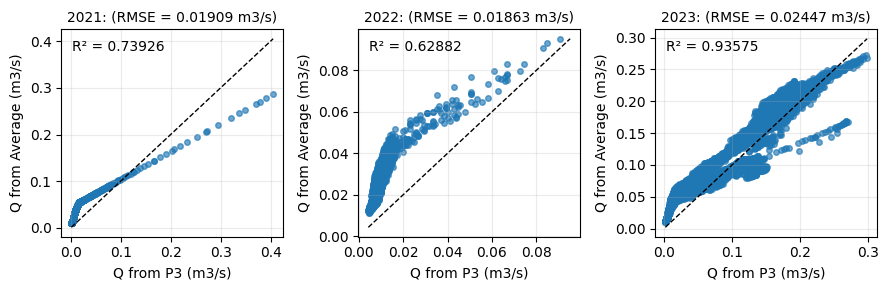

In [10]:
def rmse(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    return np.sqrt(np.mean((a - b) ** 2))

def r2(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    if len(a) < 2 or np.std(a) == 0 or np.std(b) == 0:
        return np.nan
    return np.corrcoef(a, b)[0, 1] ** 2

fig, axes = plt.subplots(1, 3, figsize=(9, 3))

year_data = [
    ("2021", discharge_2021),
    ("2022", discharge_2022),
    ("2023", discharge_2023),
]

for ax, (year, df) in zip(axes, year_data):
    # Keep only rows where both modeled series exist
    comp = df[["P3", "avg"]].dropna()

    # Exclude spring 2022 (March, April, May)
    if year == "2022":
        comp = comp[~comp.index.month.isin([3, 4, 5])]

    # RMSE between the two modeled methods
    year_rmse = rmse(comp["P3"], comp["avg"])
    year_r2 = r2(comp["P3"], comp["avg"])

    # Scatter: x = P3 method, y = avg method
    ax.scatter(comp["P3"], comp["avg"], s=16, alpha=0.65, color="tab:blue")

    # 1:1 reference line
    vmin = comp[["P3", "avg"]].min().min()
    vmax = comp[["P3", "avg"]].max().max()
    ax.plot([vmin, vmax], [vmin, vmax], "k--", linewidth=1)

    ax.set_title(f"{year}: (RMSE = {year_rmse:.5f} m3/s)", fontsize=10)
    ax.text(0.05, 0.95, f"R² = {year_r2:.5f}", transform=ax.transAxes, verticalalignment='top')
    ax.set_xlabel("Q from P3 (m3/s)")
    ax.set_ylabel("Q from Average (m3/s)")
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

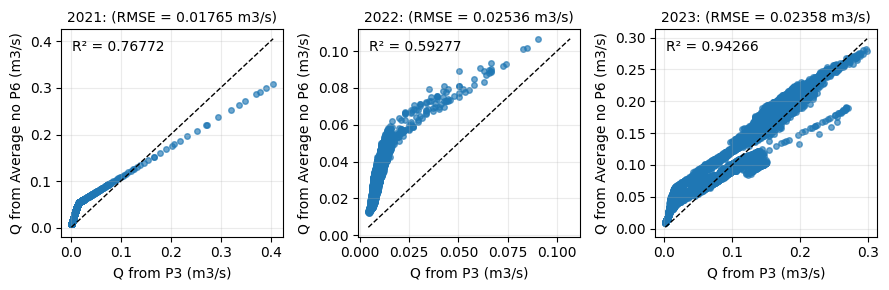

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

year_data = [
    ("2021", discharge_2021),
    ("2022", discharge_2022),
    ("2023", discharge_2023),
]

for ax, (year, df) in zip(axes, year_data):
    # Keep only rows where both modeled series exist
    comp = df[["P3", "avg_nop6"]].dropna()

    if year == "2022":
        comp = comp[~comp.index.month.isin([3, 4, 5])]

    # RMSE between the two modeled methods
    year_rmse = rmse(comp["P3"], comp["avg_nop6"])
    year_r2 = r2(comp["P3"], comp["avg_nop6"])

    # Scatter: x = P3 method, y = avg method
    ax.scatter(comp["P3"], comp["avg_nop6"], s=16, alpha=0.65, color="tab:blue")

    # 1:1 reference line
    vmin = comp[["P3", "avg_nop6"]].min().min()
    vmax = comp[["P3", "avg_nop6"]].max().max()
    ax.plot([vmin, vmax], [vmin, vmax], "k--", linewidth=1)

    ax.set_title(f"{year}: (RMSE = {year_rmse:.5f} m3/s)", fontsize=10)
    ax.text(0.05, 0.95, f"R² = {year_r2:.5f}", transform=ax.transAxes, verticalalignment='top')
    ax.set_xlabel("Q from P3 (m3/s)")
    ax.set_ylabel("Q from Average no P6 (m3/s)")
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

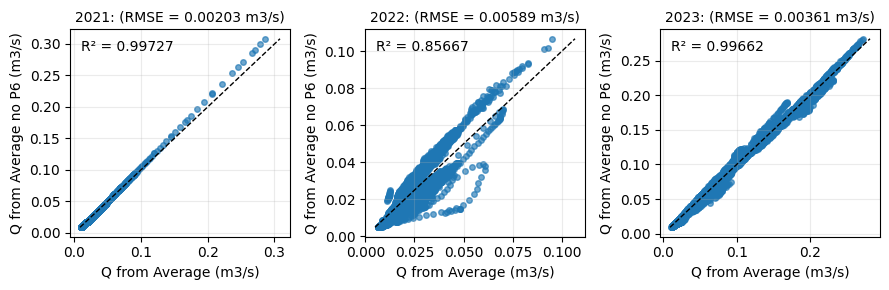

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

year_data = [
    ("2021", discharge_2021),
    ("2022", discharge_2022),
    ("2023", discharge_2023),
]

for ax, (year, df) in zip(axes, year_data):
    # Keep only rows where both modeled series exist
    comp = df[["avg", "avg_nop6"]].dropna()

    # RMSE between the two modeled methods
    year_rmse = rmse(comp["avg"], comp["avg_nop6"])
    year_r2 = r2(comp["avg"], comp["avg_nop6"])

    # Scatter: x = P3 method, y = avg method
    ax.scatter(comp["avg"], comp["avg_nop6"], s=16, alpha=0.65, color="tab:blue")

    # 1:1 reference line
    vmin = comp[["avg", "avg_nop6"]].min().min()
    vmax = comp[["avg", "avg_nop6"]].max().max()
    ax.plot([vmin, vmax], [vmin, vmax], "k--", linewidth=1)

    ax.set_title(f"{year}: (RMSE = {year_rmse:.5f} m3/s)", fontsize=10)
    ax.text(0.05, 0.95, f"R² = {year_r2:.5f}", transform=ax.transAxes, verticalalignment='top')
    ax.set_xlabel("Q from Average (m3/s)")
    ax.set_ylabel("Q from Average no P6 (m3/s)")
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()